# Imports & Φόρτωση

In [8]:
# Konstantinos Apostolos Kotsopoulos 10969
# Nikolaos Stanotas 1730

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.decomposition import PCA

# Μοντέλα
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Επιλογή μοντέλου
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix


# Φόρτωση Train Data
df_train = pd.read_csv('datasetTV.csv', header=None)

# Διαχωρισμός χαρακτηριστικών (X) και ετικετών (y)
X_raw = df_train.iloc[:, :-1].values
y_raw = df_train.iloc[:, -1].values

#  Φόρτωση Δεδομένων Test Set
df_test = pd.read_csv('datasetTest.csv', header=None)
X_test_submission = df_test.values


# Μοντελοποίηση & Επιλογή

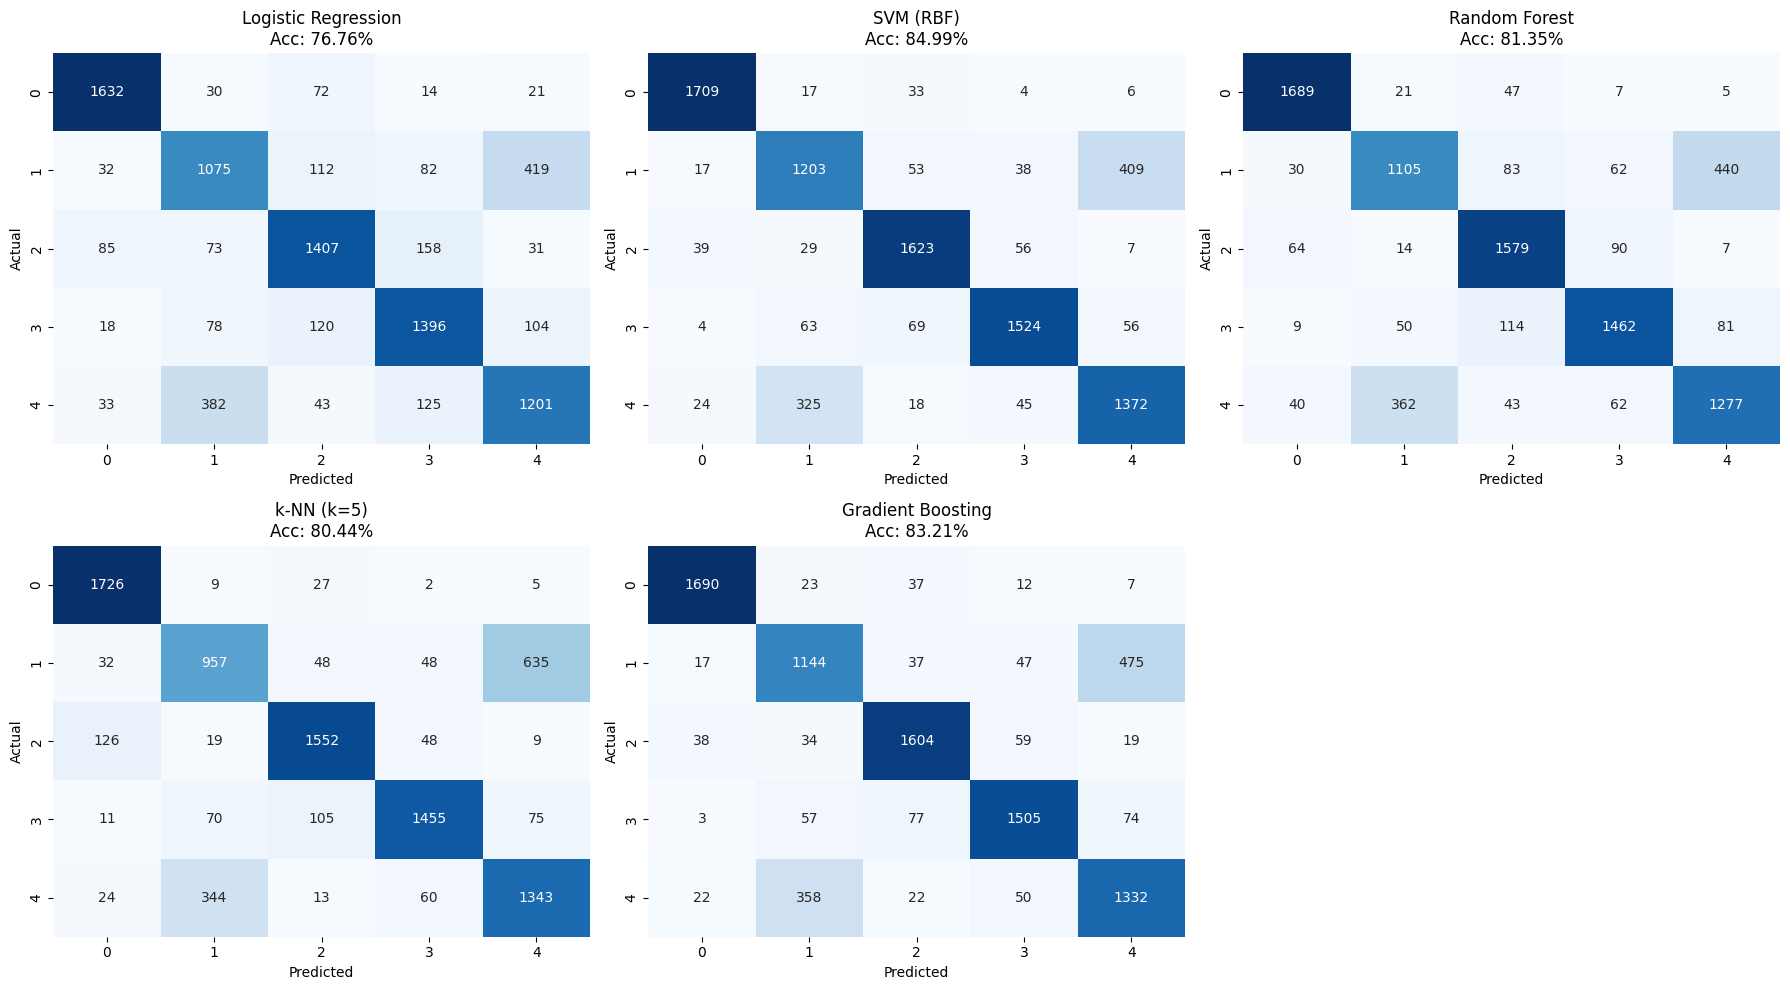

In [9]:
classifiers = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    "SVM (RBF)": Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('svm', SVC(kernel='rbf', C=5, gamma='scale', class_weight='balanced', random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    "k-NN (k=5)": Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ]),
    "Gradient Boosting": HistGradientBoostingClassifier(class_weight='balanced', random_state=42)
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(classifiers.items()):
    # Χρησιμοποιούμε Cross-Val Predict
    y_pred = cross_val_predict(model, X_raw, y_raw, cv=3, n_jobs=-1)
    acc = accuracy_score(y_raw, y_pred)
    cm = confusion_matrix(y_raw, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"{name}\nAcc: {acc*100:.2f}%")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

fig.delaxes(axes[5]) # Σβήνουμε το κενό plot
plt.tight_layout()
plt.show()

# Αναζήτηση βέλτιστου C (Grid Search)

In [10]:
# Group A (Κλάσεις 1,3 και 4)
mask_A = np.isin(y_raw, [1, 3, 4])
X_A, y_A = X_raw[mask_A], y_raw[mask_A]

pipe_A = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])
param_grid = {'svm__C': [1, 5, 10], 'svm__gamma': ['scale', 'auto']}
grid_A = GridSearchCV(pipe_A, param_grid, cv=3, n_jobs=-1)
grid_A.fit(X_A, y_A)
print(f" Group A Best: {grid_A.best_params_} (Score: {grid_A.best_score_:.4f})")

# Group B (Κλάσεις 2 και 5)
mask_B = np.isin(y_raw, [2, 5])
X_B, y_B = X_raw[mask_B], y_raw[mask_B]

# Για αυτο το group χρησιμοποιουμε normalizer επειδη εδωσε υψηλότερη ακρίβεια
pipe_B = Pipeline([
    ('norm', Normalizer()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])
param_grid_B = {'svm__C': [1, 5, 10, 50]}
grid_B = GridSearchCV(pipe_B, param_grid_B, cv=3, n_jobs=-1)
grid_B.fit(X_B, y_B)
print(f" Group B Best: {grid_B.best_params_} (Score: {grid_B.best_score_:.4f})")

 Group A Best: {'svm__C': 5, 'svm__gamma': 'auto'} (Score: 0.9546)
 Group B Best: {'svm__C': 5} (Score: 0.7828)


# Τελική Εκπαίδευση Ιεραρχικού Μοντέλου & Εξαγωγή Αποτελεσμάτων

In [11]:

# Ορισμός των Pipelines (Με τις παραμέτρους που βρήκαμε)
# Διαχωρίζουμε τα δείγματα σε group A και group B
pipe_sep = Pipeline([
    ('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)),
    ('svm', SVC(kernel='rbf', C=5, gamma='scale', class_weight='balanced', random_state=42))
])
# Group A (1,3,4)
pipe_A = Pipeline([
    ('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)),
    ('svm', SVC(kernel='rbf', C=5, gamma='scale', class_weight='balanced', random_state=42))
])
# Group B (2,5) - Με Normalizer
pipe_B = Pipeline([
    ('norm', Normalizer()), ('pca', PCA(n_components=0.95)),
    ('svm', SVC(kernel='rbf', C=5, gamma='scale', class_weight='balanced', random_state=42))
])

# Συνάρτηση πρόβλεψης
def hierarchical_predict_logic(X_train, y_train, X_query):
    # Εκπαίδευση

    # Separator
    y_bin = np.isin(y_train, [2, 5]).astype(int)
    pipe_sep.fit(X_train, y_bin)

    # Group A
    mask_A = np.isin(y_train, [1, 3, 4])
    if np.sum(mask_A) > 0:
        pipe_A.fit(X_train[mask_A], y_train[mask_A])

    # Group B
    mask_B = np.isin(y_train, [2, 5])
    if np.sum(mask_B) > 0:
        pipe_B.fit(X_train[mask_B], y_train[mask_B])

    # Πρόβλεψη
    preds_bin = pipe_sep.predict(X_query)
    final_preds = np.zeros(len(X_query))

    idx_A = np.where(preds_bin == 0)[0]
    idx_B = np.where(preds_bin == 1)[0]

    if len(idx_A) > 0:
        final_preds[idx_A] = pipe_A.predict(X_query[idx_A])
    if len(idx_B) > 0:
        final_preds[idx_B] = pipe_B.predict(X_query[idx_B])

    return final_preds

# Υπολογισμός ακρίβειας
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_raw, y_raw)):
    X_tr, X_val = X_raw[train_idx], X_raw[val_idx]
    y_tr, y_val = y_raw[train_idx], y_raw[val_idx]

    # Πρόβλεψη στο validation set
    preds = hierarchical_predict_logic(X_tr, y_tr, X_val)
    acc = accuracy_score(y_val, preds)
    cv_scores.append(acc)

# Υπολογισμός μέσου όρου
calculated_acc = np.mean(cv_scores) * 100

# Τελική Εκπαίδευση σε όλα τα δεδομένα και Εξαγωγή
final_predictions = hierarchical_predict_logic(X_raw, y_raw, X_test_submission)

TEAM_NUMBER = "22"
filename = f"labels{TEAM_NUMBER}.npy"
np.save(filename, final_predictions)

print(f" Το αρχείο '{filename}' αποθηκεύτηκε.")
print(f" Υπολογισμένη Ακριβεία (CV Score): {calculated_acc:.2f}%")

 Το αρχείο 'labels22.npy' αποθηκεύτηκε.
 Υπολογισμένη Ακριβεία (CV Score): 86.03%
